In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib
import seaborn as sns
import matplotlib.pyplot as plt
import networkx as nx
import community.community_louvain as community_louvain
import matplotlib.lines as mlines
import networkx as nx
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

In [3]:
# =========================================
# 1) Cargar dataframes desde Google Sheets
# =========================================
!pip -q install python-louvain

import pandas as pd
import networkx as nx

# Import robusto Louvain
try:
    import community.community_louvain as community_louvain
except Exception:
    import community as community_louvain

def read_gsheet_csv(file_id: str, gid: str) -> pd.DataFrame:
    url = f"https://docs.google.com/spreadsheets/d/{file_id}/export?format=csv&gid={gid}"
    return pd.read_csv(url)

file_id = "1eF4cQzhcVA1-7imS-aMi2NGE6y5jFQlS"

author_edges_year = read_gsheet_csv(file_id, "1106599086")
author_ego_edges_top10 = read_gsheet_csv(file_id, "866503778")
author_ego_nodes_top10 = read_gsheet_csv(file_id, "204963698")

print("author_edges_year:", author_edges_year.shape, author_edges_year.columns.tolist())
print("author_ego_edges_top10:", author_ego_edges_top10.shape, author_ego_edges_top10.columns.tolist())
print("author_ego_nodes_top10:", author_ego_nodes_top10.shape, author_ego_nodes_top10.columns.tolist())


author_edges_year: (33155, 3) ['Source', 'Target', 'Year']
author_ego_edges_top10: (300987, 4) ['source_personid', 'target_personid', 'weight', 'SR_list']
author_ego_nodes_top10: (3127, 4) ['PersonID', 'AuthorName', 'AuthorFullName', 'is_top_author']


In [4]:
# =========================================
# 2) Funciones actualizadas para los nuevos dataframes
#    author_edges_year -> columnas: Source, Target, Year
# =========================================
def _add_louvain_communities(G: nx.Graph, random_state: int = 42) -> nx.Graph:
    if G.number_of_nodes() == 0:
        return G

    communities = community_louvain.best_partition(G, random_state=random_state)

    # Reindexar comunidades por tamaño (mayor = comunidad 1)
    comm_sizes = {}
    for node, comm in communities.items():
        comm_sizes[comm] = comm_sizes.get(comm, 0) + 1
    sorted_comms = sorted(comm_sizes, key=comm_sizes.get, reverse=True)
    mapping = {old: i + 1 for i, old in enumerate(sorted_comms)}
    communities_reindexed = {n: mapping[c] for n, c in communities.items()}

    nx.set_node_attributes(G, communities_reindexed, "community")
    return G


def create_author_network(author_edges_year_df: pd.DataFrame,
                          filter_components: bool = True,
                          random_state: int = 42) -> nx.Graph:
    df = author_edges_year_df[["Source", "Target", "Year"]].copy()

    for c in ["Source", "Target"]:
        df[c] = df[c].astype(str).str.strip()
        df.loc[df[c].str.lower().isin(["", "nan", "none", "null"]), c] = pd.NA

    df["Year"] = pd.to_numeric(df["Year"], errors="coerce")
    df = df.dropna(subset=["Source", "Target", "Year"])
    df = df[df["Source"] != df["Target"]]

    # Grafo no dirigido (temporal sin peso agregado)
    G = nx.from_pandas_edgelist(
        df,
        source="Source",
        target="Target",
        edge_attr="Year",
        create_using=nx.Graph()
    )

    if filter_components and G.number_of_nodes() > 0:
        largest_cc = max(nx.connected_components(G), key=len)
        G = G.subgraph(largest_cc).copy()

    degree_dict = dict(G.degree())
    nx.set_node_attributes(G, degree_dict, "degree")

    G = _add_louvain_communities(G, random_state=random_state)
    return G


def create_weighted_author_network(author_edges_year_df: pd.DataFrame,
                                   filter_components: bool = True,
                                   random_state: int = 42) -> nx.Graph:
    df = author_edges_year_df[["Source", "Target"]].copy()

    for c in ["Source", "Target"]:
        df[c] = df[c].astype(str).str.strip()
        df.loc[df[c].str.lower().isin(["", "nan", "none", "null"]), c] = pd.NA

    df = df.dropna(subset=["Source", "Target"])
    df = df[df["Source"] != df["Target"]]

    # Normalizar par no dirigido para evitar duplicidad A-B / B-A
    df["u"] = df[["Source", "Target"]].min(axis=1)
    df["v"] = df[["Source", "Target"]].max(axis=1)

    edge_weights = (
        df.groupby(["u", "v"], as_index=False)
          .size()
          .rename(columns={"size": "Weight"})
    )

    G = nx.from_pandas_edgelist(
        edge_weights,
        source="u",
        target="v",
        edge_attr="Weight",
        create_using=nx.Graph()
    )

    if filter_components and G.number_of_nodes() > 0:
        largest_cc = max(nx.connected_components(G), key=len)
        G = G.subgraph(largest_cc).copy()

    nx.set_node_attributes(G, dict(G.degree()), "degree")
    nx.set_node_attributes(G, dict(G.degree(weight="Weight")), "weighted_degree")

    G = _add_louvain_communities(G, random_state=random_state)
    return G


In [5]:
# =========================================
# 4) Uso
# =========================================
author_network_time = create_author_network(author_edges_year)
author_network = create_weighted_author_network(author_edges_year)

In [6]:
# Actualizado para author_edges_year con columnas: Source, Target, Year

import pandas as pd
import networkx as nx

# Import robusto de Louvain
try:
    import community.community_louvain as community_louvain
except Exception:
    import community as community_louvain

# 1) Limpiar datos
df = author_edges_year[["Source", "Target", "Year"]].copy()

for c in ["Source", "Target"]:
    df[c] = df[c].astype(str).str.strip()
    df.loc[df[c].str.lower().isin(["", "nan", "none", "null"]), c] = pd.NA

df["Year"] = pd.to_numeric(df["Year"], errors="coerce")
df = df.dropna(subset=["Source", "Target", "Year"])
df = df[df["Source"] != df["Target"]]

# 2) Grafo no dirigido temporal
G = nx.from_pandas_edgelist(
    df,
    source="Source",
    target="Target",
    edge_attr="Year",
    create_using=nx.Graph()
)

# 3) Componente gigante
largest_cc = max(nx.connected_components(G), key=len)
G_sub = G.subgraph(largest_cc).copy()

# 4) Primer año de colaboración por autor (usando Source + Target)
year_from = df.groupby("Source")["Year"].min().rename("y1")
year_to = df.groupby("Target")["Year"].min().rename("y2")
first_year = pd.concat([year_from, year_to], axis=1).min(axis=1).dropna().astype(int).to_dict()
nx.set_node_attributes(G_sub, first_year, "Year")

# 5) Grado y comunidades
degree_dict = dict(G_sub.degree())
nx.set_node_attributes(G_sub, degree_dict, "degree")

partition = community_louvain.best_partition(G_sub, random_state=42)

# Reindexar comunidades por tamaño (mayor -> 1, 2, 3...)
comm_sizes = {}
for n, c in partition.items():
    comm_sizes[c] = comm_sizes.get(c, 0) + 1
sorted_comms = sorted(comm_sizes, key=comm_sizes.get, reverse=True)
comm_map = {old: i + 1 for i, old in enumerate(sorted_comms)}
partition_reindexed = {n: comm_map[c] for n, c in partition.items()}

# 6) DataFrame final de nodos
author_network_time = pd.DataFrame({
    "author": list(G_sub.nodes()),
    "degree": [degree_dict[n] for n in G_sub.nodes()],
    "community": [partition_reindexed[n] for n in G_sub.nodes()],
    "Year": [G_sub.nodes[n].get("Year", None) for n in G_sub.nodes()],
})

author_network_time.head()


,author,degree,community,Year
0,"TOMAS, ROSLIN",103,3,2022
1,"ANDRES, F. NAVIA",32,7,2023
2,"ANTONIO, PUNZON",11,2,2024
3,"HEO, JIMAN",13,4,2022
4,"FRANCESCA, FESTA",27,10,2023


<Figure size 640x480 with 0 Axes>

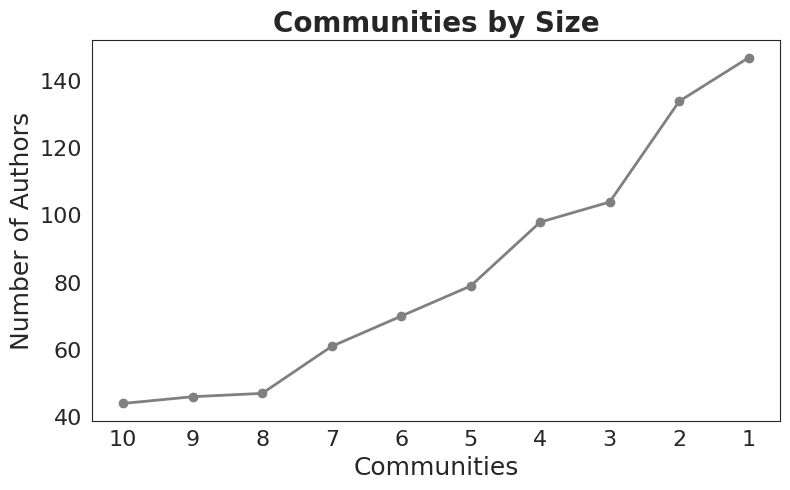

   community    n  x_axis
0         10   44       0
1          9   46       1
2          8   47       2
3          7   61       3
4          6   70       4
5          5   79       5
6          4   98       6
7          3  104       7
8          2  134       8
9          1  147       9


In [7]:
# Actualizado para author_network (grafo de autores, no journals)

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Nodos con atributos desde el grafo
nodes_df = pd.DataFrame.from_dict(dict(author_network.nodes(data=True)), orient="index")
nodes_df["node"] = nodes_df.index
nodes_df.reset_index(drop=True, inplace=True)

# Asegurar comunidad numérica
nodes_df["community"] = pd.to_numeric(nodes_df["community"], errors="coerce")
nodes_df = nodes_df.dropna(subset=["community"]).copy()
nodes_df["community"] = nodes_df["community"].astype(int)

# Top 10 comunidades más grandes
community_counts = (
    nodes_df["community"]
    .value_counts()
    .rename_axis("community")
    .reset_index(name="n")
    .sort_values("n", ascending=False)
    .head(10)
)

# Orden ascendente para trazo
community_counts = community_counts.sort_values("n", ascending=True).reset_index(drop=True)
community_counts["x_axis"] = range(len(community_counts))

sns.set_style("white")
sns.despine()

plt.figure(figsize=(8, 5))
plt.plot(
    community_counts["x_axis"],
    community_counts["n"],
    marker="o",
    linestyle="-",
    color="gray",
    linewidth=2,
    markersize=6
)

plt.title("Communities by Size", fontsize=20, weight="bold")
plt.xlabel("Communities", fontsize=18)
plt.ylabel("Number of Authors", fontsize=18)  # <- actualizado

plt.xticks(community_counts["x_axis"], community_counts["community"], fontsize=16)
plt.yticks(fontsize=16)

plt.grid(False)
plt.tight_layout()
plt.savefig("figura_4a.svg", format="svg")
plt.show()

print(community_counts)


# Figure 4b Longitudinal

In [11]:
# Actualizado para author_edges_year con columnas: Source, Target, Year

import pandas as pd

# Define rango (ajústalo si quieres)
start_year = 2022
year_end = 2026

# Base limpia
edges_df = author_edges_year[["Source", "Target", "Year"]].copy()
for c in ["Source", "Target"]:
    edges_df[c] = edges_df[c].astype(str).str.strip()
    edges_df.loc[edges_df[c].str.lower().isin(["", "nan", "none", "null"]), c] = pd.NA

edges_df["Year"] = pd.to_numeric(edges_df["Year"], errors="coerce")
edges_df = edges_df.dropna(subset=["Source", "Target", "Year"])
edges_df = edges_df[edges_df["Source"] != edges_df["Target"]].copy()
edges_df["Year"] = edges_df["Year"].astype(int)

# -------------------------
# Serie de links por año
# -------------------------
fig_1c_edges = (
    edges_df[["Year"]]
    .groupby("Year")
    .size()
    .reset_index(name="n")
    .query("Year >= @start_year and Year <= @year_end")
    .assign(percentage=lambda x: x["n"] / x["n"].max())
    [["Year", "percentage"]]
    .rename(columns={"Year": "year"})
)

# -------------------------
# Serie de nodos por año
# (primer año en que aparece cada autor)
# -------------------------
fig_1c_nodes = (
    pd.concat([
        edges_df.rename(columns={"Source": "author", "Year": "year"})[["author", "year"]],
        edges_df.rename(columns={"Target": "author", "Year": "year"})[["author", "year"]],
    ], ignore_index=True)
    .drop_duplicates()
    .sort_values("year")
    .groupby("author", as_index=False)
    .first()
    .groupby("year")
    .size()
    .reset_index(name="n")
    .query("year >= @start_year and year <= @year_end")
    .assign(percentage=lambda x: x["n"] / x["n"].max())
    [["year", "percentage"]]
)

fig_1c_edges.head(), fig_1c_nodes.head()


(   year  percentage
 0  2022    1.000000
 1  2023    0.270905
 2  2024    0.207642
 3  2025    0.216411
 4  2026    0.035338,
    year  percentage
 0  2022    0.866109
 1  2023    0.711297
 2  2024    0.674686
 3  2025    1.000000
 4  2026    0.180962)

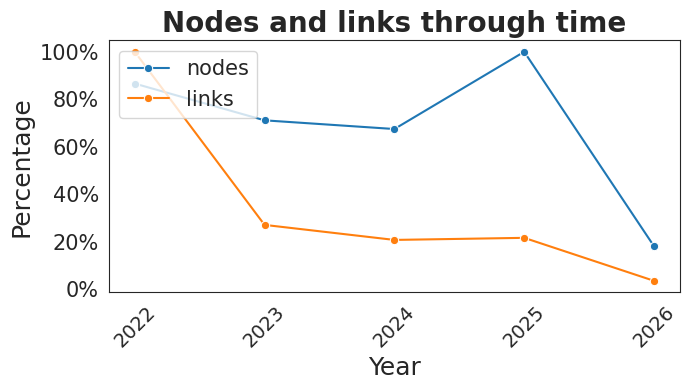

In [12]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

# Etiquetas de tipo
fig_1c_nodes_plot = fig_1c_nodes.copy()
fig_1c_edges_plot = fig_1c_edges.copy()
fig_1c_nodes_plot["type"] = "nodes"
fig_1c_edges_plot["type"] = "links"

data = pd.concat([fig_1c_nodes_plot, fig_1c_edges_plot], ignore_index=True)

# Completar años faltantes con 0 para ambas series
years = pd.DataFrame({"year": np.arange(start_year, year_end + 1)})
filled = []
for t in ["nodes", "links"]:
    d = data[data["type"] == t][["year", "percentage"]]
    d = years.merge(d, on="year", how="left")
    d["percentage"] = d["percentage"].fillna(0)
    d["type"] = t
    filled.append(d)

data_plot = pd.concat(filled, ignore_index=True)

plt.figure(figsize=(7, 4))
sns.lineplot(data=data_plot, x="year", y="percentage", hue="type", marker="o")

plt.xlabel("Year", fontsize=18)
plt.ylabel("Percentage", fontsize=18)
plt.title("Nodes and links through time", fontsize=20, weight="bold")
plt.xticks(np.arange(start_year, year_end + 1, step=1), rotation=45, fontsize=14)
plt.yticks(fontsize=15)
plt.legend(title=None, fontsize=15, loc="upper left")

# Eje Y como porcentaje (valores 0..1)
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
plt.grid(False)
plt.tight_layout()

# Guardar sin carpeta adicional
plt.savefig("figura_4b.svg", format="svg", bbox_inches="tight")
plt.show()


# Figure 4c

/tmp/ipykernel_1745/1683770041.py:115: UserWarning: Glyph 129 (\x81) missing from font(s) DejaVu Sans.
  plt.savefig("figura_4c.svg", format="svg")
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 129 (\x81) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


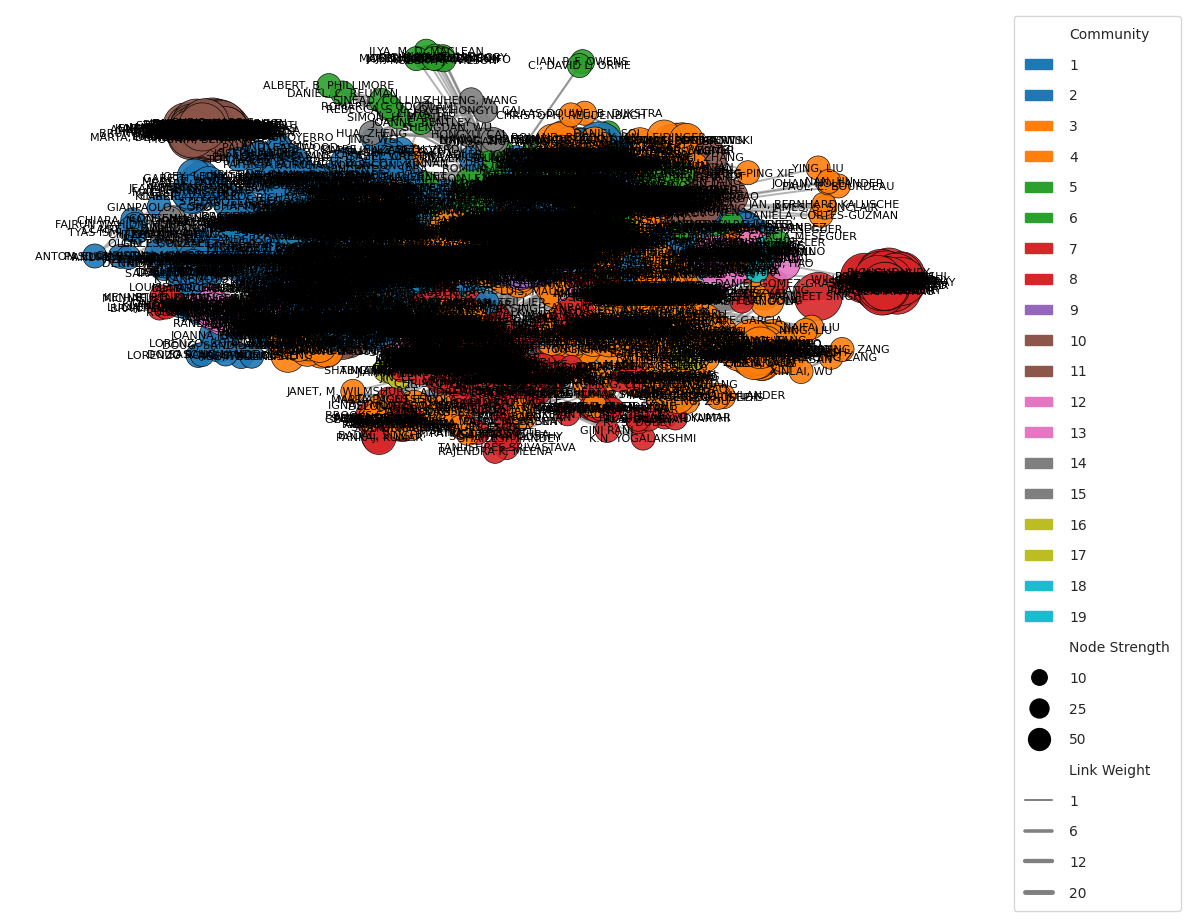

In [14]:
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

try:
    import community.community_louvain as community_louvain
except Exception:
    import community as community_louvain

# 1) Grafo desde datos top10 (ya filtrados)
edges = author_ego_edges_top10.copy()
edges["weight"] = pd.to_numeric(edges["weight"], errors="coerce").fillna(1.0)

G = nx.from_pandas_edgelist(
    edges,
    source="source_personid",
    target="target_personid",
    edge_attr="weight",
    create_using=nx.Graph()
)
G.remove_edges_from(nx.selfloop_edges(G))

# 2) Atributos de nodos
nodes = author_ego_nodes_top10.copy()
nodes["PersonID"] = nodes["PersonID"].astype(str).str.strip()
name_map = dict(zip(nodes["PersonID"], nodes.get("AuthorFullName", nodes["PersonID"])))
nx.set_node_attributes(G, name_map, "label")

# 3) Degree + comunidades
nx.set_node_attributes(G, dict(G.degree()), "degree")
nx.set_node_attributes(G, dict(G.degree(weight="weight")), "weighted_degree")

partition = community_louvain.best_partition(G, random_state=42)
sizes = pd.Series(list(partition.values())).value_counts()
comm_order = {c: i + 1 for i, c in enumerate(sizes.index.tolist())}
partition = {n: comm_order[c] for n, c in partition.items()}
nx.set_node_attributes(G, partition, "community")

# 4) Layout
pos = nx.spring_layout(G, seed=42)

# 5) Funciones de mapeo
def map_strength_to_size(s):
    if s < 10: return 300
    if s < 25: return 600
    if s < 50: return 900
    return 1200

def map_weight_to_width(w):
    return 0.8 + 0.9 * np.log1p(max(w, 1))

node_strength = nx.get_node_attributes(G, "weighted_degree")
node_sizes = [map_strength_to_size(node_strength.get(n, 0)) for n in G.nodes()]

communities = sorted(set(nx.get_node_attributes(G, "community").values()))
cmap = plt.get_cmap("tab10", len(communities))
node_colors = [cmap(communities.index(G.nodes[n]["community"])) for n in G.nodes()]

edge_weights = [G[u][v].get("weight", 1.0) for u, v in G.edges()]
edge_widths = [map_weight_to_width(w) for w in edge_weights]

# 6) Plot (Python)
plt.figure(figsize=(12, 8))
nx.draw_networkx_nodes(
    G, pos, node_color=node_colors, node_size=node_sizes,
    alpha=0.9, edgecolors="black", linewidths=0.5
)
nx.draw_networkx_edges(
    G, pos, width=edge_widths, alpha=0.6, edge_color="gray"
)
nx.draw_networkx_labels(
    G, pos, labels=nx.get_node_attributes(G, "label"), font_size=8
)

# 7) Leyendas
community_legend = [Line2D([], [], color="none", label="Community")] + [
    Patch(color=cmap(i), label=str(c)) for i, c in enumerate(communities)
]

strength_ticks = [10, 25, 50]
strength_legend = [Line2D([], [], color="none", label="Node Strength")] + [
    Line2D(
        [0], [0], marker="o", color="w", label=str(v),
        markerfacecolor="black", markeredgecolor="black",
        markersize=np.sqrt(map_strength_to_size(v)) / 2.2
    )
    for v in strength_ticks
]

unique_w = sorted(set(int(w) for w in edge_weights if w is not None))
if len(unique_w) >= 4:
    w_sel = [unique_w[0], unique_w[len(unique_w)//3], unique_w[2*len(unique_w)//3], unique_w[-1]]
else:
    w_sel = unique_w

link_legend = [Line2D([], [], color="none", label="Link Weight")] + [
    Line2D([0], [0], color="gray", lw=map_weight_to_width(w), label=str(int(w)))
    for w in w_sel
]

plt.legend(
    handles=community_legend + strength_legend + link_legend,
    loc="upper left",
    bbox_to_anchor=(1.02, 1),
    labelspacing=1.2,
    handletextpad=1.2,
    borderpad=0.8
)

plt.axis("off")
plt.tight_layout()
plt.savefig("figura_4c.svg", format="svg")
plt.show()

# ================================
# 🔥 8) EXPORTACIÓN CORRECTA A GEPHI
# ================================

for node in G.nodes():
    # Posición
    x, y = pos[node]

    # Color
    r, g, b, _ = cmap(communities.index(G.nodes[node]["community"]))

    # Tamaño
    size = map_strength_to_size(node_strength.get(node, 0)) / 100

    # Formato viz (Gephi lo reconoce perfecto)
    G.nodes[node]['viz'] = {
        'position': {'x': float(x), 'y': float(y), 'z': 0.0},
        'color': {'r': int(r * 255), 'g': int(g * 255), 'b': int(b * 255)},
        'size': float(size)
    }

# Guardar archivo
nx.write_gexf(G, "autores_collaboration_graph_louvain.gexf")